In [14]:

# --- 1. Importer og seed ---
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
# --- 2. Monter Drive ---
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROCESSED = Path("/content/drive/MyDrive/processed")
print("Filer:", [f.name for f in PROCESSED.iterdir()])

Filer: ['X_val.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'label_encoder.pkl', 'X_test.npy', 'X_train.npy', 'baseline_best.keras', 'baseline_training_curves.png', 'baseline_confusion_matrix.png', 'baseline_resultater.json', 'improved_best.keras', 'improved_training_curves.png', 'improved_confusion_matrix.png', 'improved_resultater.json', 'X_train_fusion.npy', 'y_val_fusion.npy', 'X_val_fusion.npy', 'X_test_fusion.npy', 'y_train_fusion.npy', 'y_test_fusion.npy', 'fusion_best.keras', 'fusion_training_curves.png', 'fusion_confusion_matrix.png', 'fusion_resultater.json', 'improved_fusion_best.keras', 'improved_fusion_training_curves.png', 'improved_fusion_confusion_matrix.png', 'improved_fusion_resultater.json']


In [16]:
# --- 3. Last inn fusion-data ---
X_train = np.load(PROCESSED / "X_train_fusion.npy")
y_train = np.load(PROCESSED / "y_train_fusion.npy")
X_val   = np.load(PROCESSED / "X_val_fusion.npy")
y_val   = np.load(PROCESSED / "y_val_fusion.npy")
X_test  = np.load(PROCESSED / "X_test_fusion.npy")
y_test  = np.load(PROCESSED / "y_test_fusion.npy")

with open(PROCESSED / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
INPUT_SHAPE = X_train.shape[1:]  # (128, 130, 3)

print(f"X_train shape : {X_train.shape}")
print(f"Input shape   : {INPUT_SHAPE}")
print(f"Klasser ({NUM_CLASSES}): {list(le.classes_)}")

X_train shape : (4695, 128, 130, 3)
Input shape   : (128, 130, 3)
Klasser (11): [np.str_('cel'), np.str_('cla'), np.str_('flu'), np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('pia'), np.str_('sax'), np.str_('tru'), np.str_('vio'), np.str_('voi')]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [17]:
# --- 4. Residual blokk ---
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same',
                                 kernel_initializer='he_uniform')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [18]:
# --- 5. Bygg improved fusion CNN ---
def build_improved_fusion(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Augmentation kun under trening (kun langs tidsaksen)
    x = layers.RandomTranslation(height_factor=0.0, width_factor=0.1)(inputs)

    # Inngangsblokk
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Residual blokker
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 256)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = residual_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="improved_fusion_cnn")

model = build_improved_fusion(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "improved_fusion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 130,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 128, 130,  │          0 │ input_layer_1[0]… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 130,  │        896 │ random_translati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 130,  │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 130,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 65,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 65,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 64, 65,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 65,    │     36,928 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 65,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 65,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 65,    │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_5[

 Total params: 2,397,003 (9.14 MB)

 Trainable params: 2,393,227 (9.13 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [19]:
# --- 6. Kompiler ---
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
# --- 7. Callbacks ---
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        str(PROCESSED / "improved_fusion_best.keras"),
        monitor='val_loss', save_best_only=True, verbose=1)
]

In [21]:
# --- 8. Tren ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=32,
    callbacks=callbacks, verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.1676 - loss: 3.1354
Epoch 1: val_loss improved from None to 4.77373, saving model to /content/drive/MyDrive/processed/improved_fusion_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/processed/improved_fusion_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 28s 134ms/step - accuracy: 0.1955 - loss: 2.7158 - val_accuracy: 0.1255 - val_loss: 4.7737 - learning_rate: 0.0010
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2773 - loss: 2.1710
Epoch 2: val_loss improved from 4.77373 to 2.57594, saving model to /content/drive/MyDrive/processed/improved_fusion_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/processed/improved_fusion_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.3022 - loss: 2.0703 - val_accuracy: 0.2490 - val_loss: 2.5759 - learning_rate: 0.0010
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3525 - loss: 1.8845
Ep

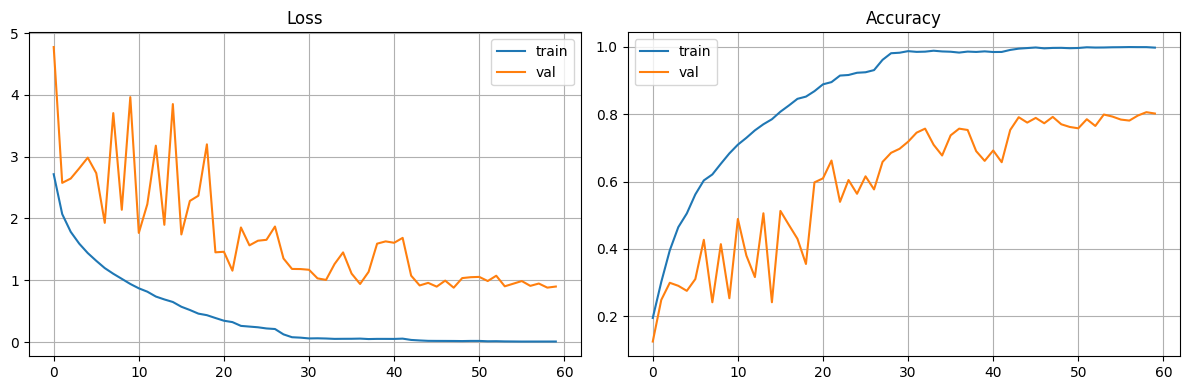

In [22]:
# --- 9. Treningskurver ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(PROCESSED / "improved_fusion_training_curves.png", dpi=150)
plt.show()

In [23]:
# --- 10. Evaluer ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test loss    : 0.9256
Test accuracy: 0.7922
              precision    recall  f1-score   support

         cel       0.63      0.86      0.73        58
         cla       0.79      0.64      0.71        76
         flu       0.74      0.78      0.76        68
         gac       0.75      0.91      0.82        96
         gel       0.83      0.68      0.75       114
         org       0.89      0.86      0.88       102
         pia       0.86      0.92      0.89       108
         sax       0.68      0.60      0.64        94
         tru       0.76      0.87      0.81        86
         vio       0.75      0.68      0.71        87
         voi       0.94      0.88      0.91       117

    accuracy                           0.79      1006
   macro avg       0.78      0.79      0.78      1006
weighted avg       0.80      0.79      0.79      1006



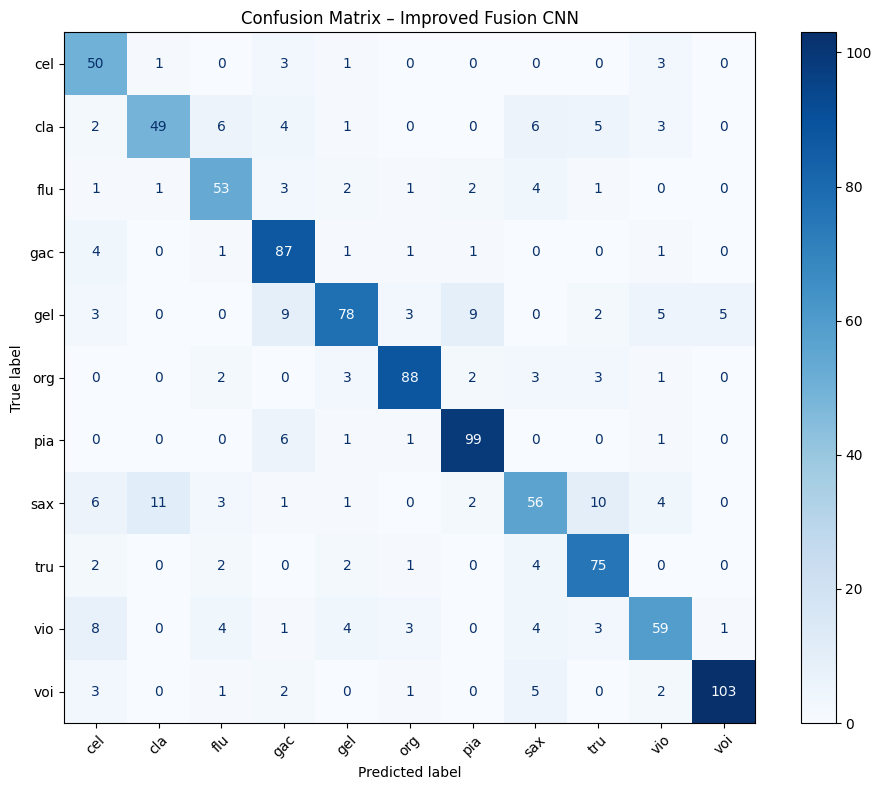

In [24]:
# --- 11. Confusion matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_,
    xticks_rotation=45, cmap='Blues', ax=ax)
plt.title("Confusion Matrix – Improved Fusion CNN")
plt.tight_layout()
plt.savefig(PROCESSED / "improved_fusion_confusion_matrix.png", dpi=150)
plt.show()

In [25]:
# --- 12. Sammenlign alle modeller ---
baseline = json.load(open(PROCESSED / "baseline_resultater.json"))
fusion   = json.load(open(PROCESSED / "fusion_resultater.json"))

print(f"\n{'Modell':<30} {'Test Acc':>10}")
print("-" * 42)
print(f"{'Dummy':<30} {baseline['dummy_accuracy']:>10.4f}")
print(f"{'Baseline CNN (mel)':<30} {baseline['test_accuracy']:>10.4f}")
print(f"{'Baseline CNN (fusion)':<30} {fusion['test_accuracy']:>10.4f}")
print(f"{'Improved CNN (fusion)':<30} {test_acc:>10.4f}")


Modell                           Test Acc
------------------------------------------
Dummy                              0.1163
Baseline CNN (mel)                 0.7286
Baseline CNN (fusion)              0.6243
Improved CNN (fusion)              0.7922


In [26]:
# --- 13. Lagre resultater ---
resultater = {
    "test_loss":     float(test_loss),
    "test_accuracy": float(test_acc),
    "epoker_trent":  len(history.history['loss']),
    "input_shape":   list(INPUT_SHAPE),
    "features":      ["mel", "mfcc", "chroma"],
    "klasser":       list(le.classes_)
}

with open(PROCESSED / "improved_fusion_resultater.json", "w") as f:
    json.dump(resultater, f, indent=2)

print("Resultater lagret!")
print(json.dumps(resultater, indent=2))

Resultater lagret!
{
  "test_loss": 0.9255551695823669,
  "test_accuracy": 0.7922465205192566,
  "epoker_trent": 60,
  "input_shape": [
    128,
    130,
    3
  ],
  "features": [
    "mel",
    "mfcc",
    "chroma"
  ],
  "klasser": [
    "cel",
    "cla",
    "flu",
    "gac",
    "gel",
    "org",
    "pia",
    "sax",
    "tru",
    "vio",
    "voi"
  ]
}
